# Table of Contents

1. Problem Statement
2. Data Loading
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Baseline ANN
7. Improved ANN
8. Architecture Comparison
9. Hyperparameter Tuning
10. Final Optimized ANN
11. Model Evaluation
12. Model Comparison
13. Best Hyperparameters
14. Conclusion

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import pickle

In [2]:
# Load the dataset
data = pd.read_csv('../data/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
data.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [6]:
# Preprocess the data
# Drop irrelevant columns
data = data.drop(['RowNumber','CustomerId','Surname'],axis=1)
data.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
data['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
data['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [10]:
## Encode categorical variables
label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [11]:
data['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
## Onehot encode Geography
geography_ohe = OneHotEncoder(drop='first', sparse_output=False)

geo_encoded = geography_ohe.fit_transform(data[['Geography']])

geo_encoded_df = pd.DataFrame(
    geo_encoded,
    columns=geography_ohe.get_feature_names_out(['Geography']),
    index=data.index
)

## Combine one hot encoder columns with the original data
data = pd.concat(
    [data.drop('Geography', axis=1), geo_encoded_df],
    axis=1
)

data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


In [13]:
## Save the encoder pkl files:
with open('../artifacts/label_encoder_gender.pkl','wb') as file:
    pickle.dump(label_encoder_gender,file)

with open('../artifacts/geography_ohe.pkl','wb') as file:
    pickle.dump(geography_ohe,file)

In [14]:
## DiVide the dataset into indepent and dependent features
X=data.drop('Exited',axis=1)
y=data['Exited']

In [15]:
## Split the data in training and tetsing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
## Scaling features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
X_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.36766974,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ...,  1.6612541 ,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.25280688,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ..., -0.1427649 ,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ..., -0.05082558,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.81456811,
         1.72572313, -0.57638802]])

In [18]:
## Save the Scaler pkl files:
with open('../artifacts/scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

In [19]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


## ANN Implementation

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [21]:
X_train.shape[1],1

(11, 1)

In [22]:
## Build our ANN Model
model = Sequential([
    Dense(64,activation='relu',input_shape = (X_train.shape[1],)),  ## HL1 Connected wwith input layer
    Dense(32,activation='relu') , ## HL2
    Dense(1,activation='sigmoid') ## output layer
])

/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-04 19:26:16.451197: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-04 19:26:16.451222: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-04 19:26:16.451228: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1785851776.451237   45311 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785851776.451250   45311 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
## compile the model
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
## setup the tensorboard
log_dir = "logs/baseline_ann/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorflow_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [26]:
## Set up early stopping
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [27]:
### Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[tensorflow_callback, early_stopping_callback]
)

Epoch 1/100


2026-08-04 19:26:16.834066: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6633 - loss: 0.6266 - val_accuracy: 0.7606 - val_loss: 0.5275
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7891 - loss: 0.4989 - val_accuracy: 0.8075 - val_loss: 0.4578
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8017 - loss: 0.4575 - val_accuracy: 0.8175 - val_loss: 0.4320
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8036 - loss: 0.4422 - val_accuracy: 0.8188 - val_loss: 0.4233
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8059 - loss: 0.4379 - val_accuracy: 0.8206 - val_loss: 0.4213
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8077 - loss: 0.4366 - val_accuracy: 0.8206 - val_loss: 0.4204
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8066 - loss: 0.4363 - val_accuracy: 0.8181 - val_loss: 0.4201
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8069 - loss: 0.4363 - val_accuracy: 0.8206

In [28]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.4153
Test Accuracy : 0.8115


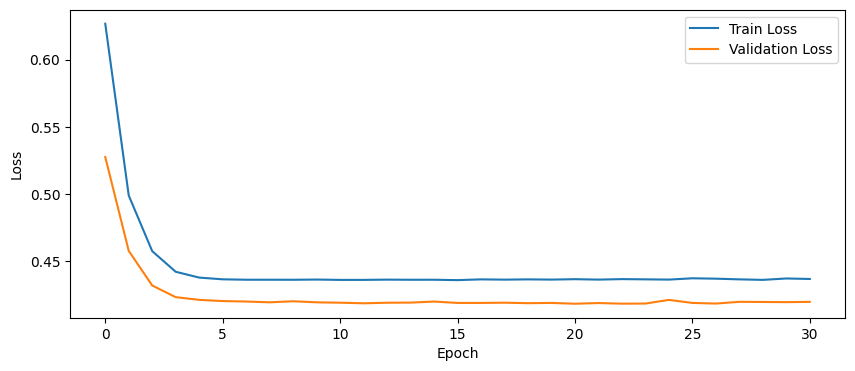

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

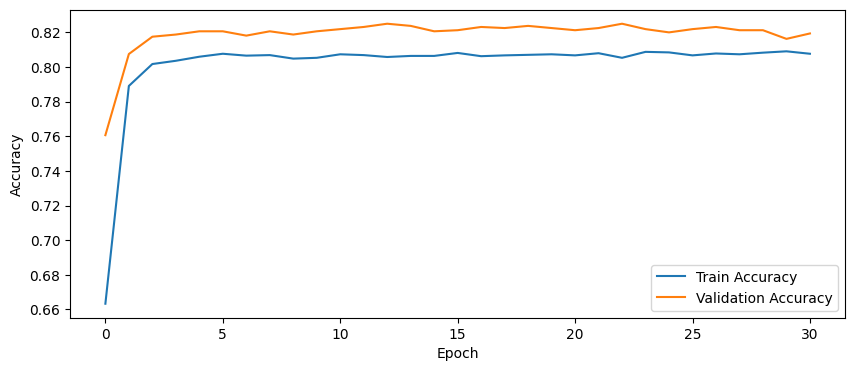

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 12. Model Evaluation

The model is evaluated on the unseen test dataset using multiple classification metrics.

The metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Classification Report

Using multiple metrics provides a better understanding of the model's performance than relying on accuracy alone, especially for imbalanced datasets such as Customer Churn Prediction.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Baseline Predictions
y_prob_baseline = model.predict(X_test, verbose=0)
y_pred_baseline = (y_prob_baseline > 0.5).astype(int).ravel()

# Store Metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_prob_baseline)

print("Baseline metrics saved successfully!")

print("="*50)
print("Baseline ANN Performance")
print("="*50)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC AUC  : {baseline_roc_auc:.4f}")

Baseline metrics saved successfully!
Baseline ANN Performance
Accuracy : 0.8115
Precision: 0.5597
Recall   : 0.1908
F1 Score : 0.2846
ROC AUC  : 0.7796


## Classification Report

The classification report provides detailed performance metrics for each class.

It contains:

- Precision
- Recall
- F1-score
- Support

This helps identify whether the model performs equally well for both churned and non-churned customers.

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.19      0.28       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



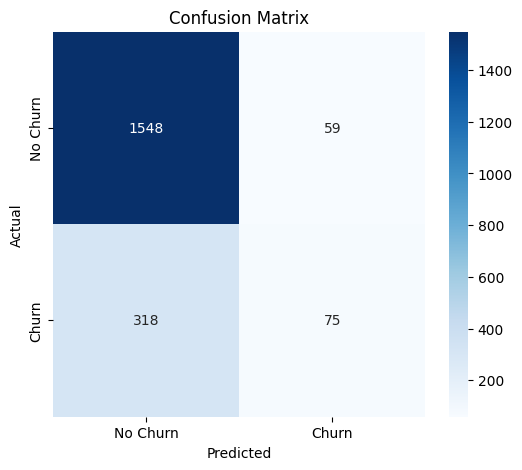

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

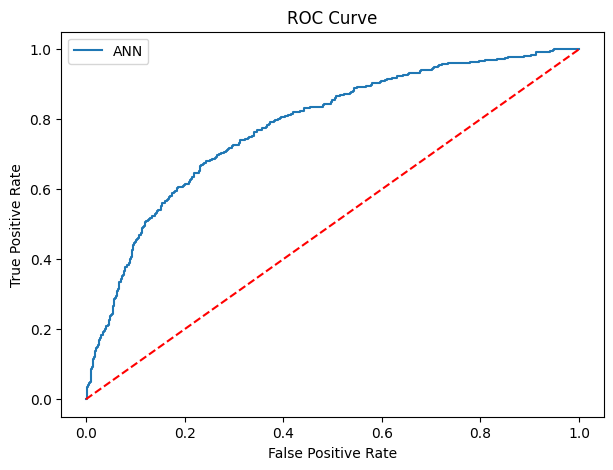

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_baseline)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="ANN")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

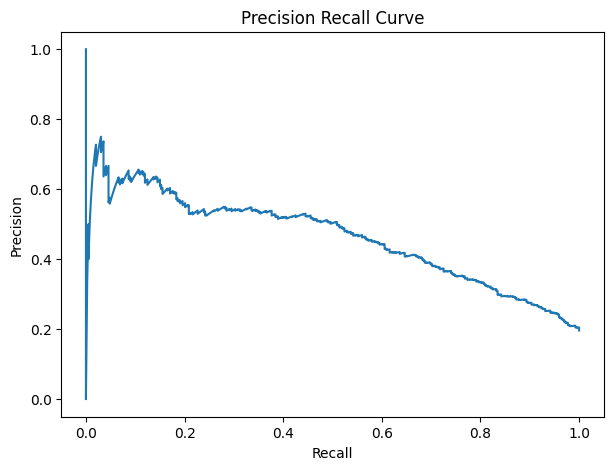

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test,y_prob_baseline)

plt.figure(figsize=(7,5))

plt.plot(recall,precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

model2 = Sequential()

model2.add(Dense(64,activation='relu',input_dim=11))
model2.add(BatchNormalization())
model2.add(Dropout(0.30))

model2.add(Dense(32,activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.20))

model2.add(Dense(1,activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
log_dir = "logs/improved_ann/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

improved_tensorboard = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [38]:
history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[improved_tensorboard, early_stopping_callback]
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7197 - loss: 0.5603 - val_accuracy: 0.8188 - val_loss: 0.4257
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7870 - loss: 0.4747 - val_accuracy: 0.8175 - val_loss: 0.4248
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7961 - loss: 0.4641 - val_accuracy: 0.8163 - val_loss: 0.4201
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7973 - loss: 0.4598 - val_accuracy: 0.8175 - val_loss: 0.4221
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8000 - loss: 0.4554 - val_accuracy: 0.8163 - val_loss: 0.4225
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8006 - loss: 0.4507 - val_accuracy: 0.8150 - val_loss: 0.4235
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8034 - loss: 0.4474 - val_accuracy: 0.8163 - val_loss: 0.4241
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8014 - loss: 0.4566 - 

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Improved ANN Predictions
y_prob_improved = model2.predict(X_test, verbose=0)

y_pred_improved = (y_prob_improved > 0.5).astype(int).ravel()

# Save Metrics
improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)
improved_roc_auc = roc_auc_score(y_test, y_prob_improved)

print("=" * 50)
print("Improved ANN Performance")
print("=" * 50)

print(f"Accuracy : {improved_accuracy:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall   : {improved_recall:.4f}")
print(f"F1 Score : {improved_f1:.4f}")
print(f"ROC AUC  : {improved_roc_auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_improved))

Improved ANN Performance
Accuracy : 0.8085
Precision: 0.5352
Recall   : 0.1934
F1 Score : 0.2841
ROC AUC  : 0.7767

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.54      0.19      0.28       393

    accuracy                           0.81      2000
   macro avg       0.68      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000



In [40]:
architectures = {

"Model A":[64,32],
"Model B":[128,64],
"Model C":[64,32,16],
"Model D":[128,64,32]

}

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, layers in architectures.items():

    model_exp = Sequential()

    model_exp.add(
        Dense(
            layers[0],
            activation="relu",
            input_dim=X_train.shape[1]
        )
    )

    for neurons in layers[1:]:
        model_exp.add(
            Dense(
                neurons,
                activation="relu"
            )
        )

    model_exp.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )

    model_exp.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
    
    log_dir = f"logs/architecture/{name}/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    architecture_tensorboard = TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    )

    history = model_exp.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        verbose=0,
        callbacks=[
            architecture_tensorboard,
            early_stop
        ]
    )

    y_prob = model_exp.predict(X_test, verbose=0)

    y_pred = (y_prob >= 0.5).astype(int)

    results.append({

        "Architecture": name,

        "Accuracy":
        accuracy_score(y_test, y_pred),

        "Precision":
        precision_score(y_test, y_pred),

        "Recall":
        recall_score(y_test, y_pred),

        "F1 Score":
        f1_score(y_test, y_pred),

        "ROC-AUC":
        roc_auc_score(y_test, y_prob),

        "Epochs":
        len(history.history["loss"])

    })

/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(sha

In [42]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison

,Architecture,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Epochs
1,Model B,0.8140,0.567742,0.223919,0.321168,0.772524,11
0,Model A,0.8150,0.559585,0.274809,0.368601,0.766787,16
2,Model C,0.8185,0.567568,0.320611,0.409756,0.759392,11
3,Model D,0.8015,0.494253,0.437659,0.464238,0.723098,11


# Architecture Comparison

Four different Artificial Neural Network architectures were evaluated.

Each model was trained using:

- Adam Optimizer
- Binary Crossentropy Loss
- Early Stopping
- Validation Split = 20%

The models were compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Number of Epochs before Early Stopping

The architecture with the highest ROC-AUC was selected as the best-performing model.

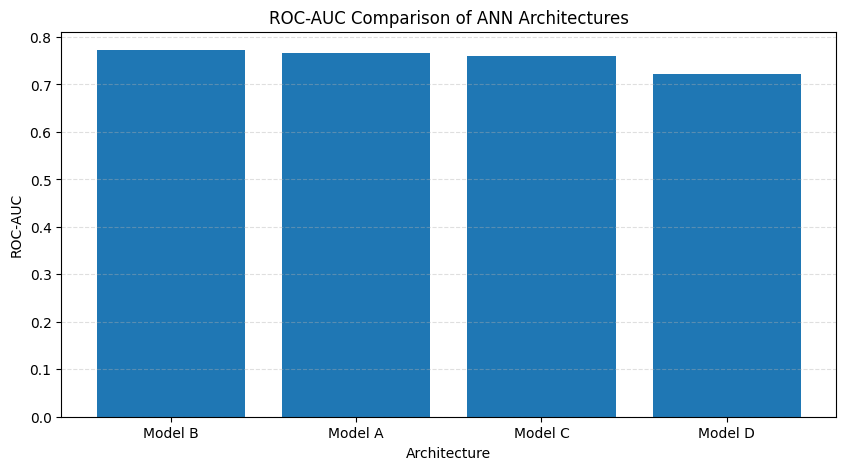

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    comparison["Architecture"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison of ANN Architectures")

plt.xlabel("Architecture")

plt.ylabel("ROC-AUC")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [45]:
models={

"Logistic Regression":
LogisticRegression(),

"Random Forest":
RandomForestClassifier(),

"XGBoost":
XGBClassifier(),

}

In [46]:
ml_results=[]

for name,clf in models.items():

    clf.fit(X_train,y_train)

    pred=clf.predict(X_test)

    ml_results.append([

        name,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred)

    ])

/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/sklearn/line

In [47]:
ml_results.append([

"ANN",

accuracy_score(y_test,y_pred),

precision_score(y_test,y_pred),

recall_score(y_test,y_pred),

f1_score(y_test,y_pred)

])

In [48]:
comparison_df=pd.DataFrame(

ml_results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1"

]

)

comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,XGBoost,0.8695,0.717105,0.554707,0.625538
1,Random Forest,0.8660,0.761506,0.463104,0.575949
0,Logistic Regression,0.8110,0.552448,0.201018,0.294776
3,ANN,0.8015,0.494253,0.437659,0.464238


In [49]:
# %load_ext tensorboard
# %tensorboard --logdir logs

# Hyperparameter Tuning

Hyperparameter tuning is the process of finding the optimal configuration of a neural network to maximize its performance on unseen data.

Instead of changing multiple parameters simultaneously, each hyperparameter is evaluated independently while keeping the remaining parameters constant. This controlled experimentation helps identify the effect of individual hyperparameters on model performance.

The following hyperparameters are explored:

- Learning Rate
- Batch Size
- Optimizer
- Activation Function
- Dropout Rate
- Number of Neurons

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(
    learning_rate=0.001,
    optimizer=None,
    activation='relu',
    dropout_rate=0.3,
    neurons1=64,
    neurons2=32
):

    if optimizer is None:
        optimizer = Adam(learning_rate=learning_rate)

    model = Sequential([
        Dense(neurons1, activation=activation, input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(neurons2, activation=activation),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [51]:
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import datetime
import matplotlib.pyplot as plt


def tune_hyperparameter(
    parameter_name,
    values,
    learning_rate=0.001,
    batch_size=32,
    optimizer_name="adam",
    activation="relu",
    dropout_rate=0.3,
    neurons1=64,
    neurons2=32
):

    results = []

    for value in values:

        print(f"\nTraining with {parameter_name}: {value}")

        # ---------------- TensorBoard ---------------- #
        log_dir = (
            f"logs/hyperparameter_tuning/{parameter_name}/{value}/"
            + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        )

        tb_callback = TensorBoard(
            log_dir=log_dir,
            histogram_freq=1
        )

        # ---------------- Hyperparameter Selection ---------------- #

        current_learning_rate = learning_rate
        current_batch_size = batch_size
        current_activation = activation
        current_dropout = dropout_rate
        current_neurons1 = neurons1
        current_neurons2 = neurons2
        current_optimizer = optimizer_name

        if parameter_name == "Learning Rate":
            current_learning_rate = value

        elif parameter_name == "Batch Size":
            current_batch_size = value

        elif parameter_name == "Activation":
            current_activation = value

        elif parameter_name == "Dropout":
            current_dropout = value

        elif parameter_name == "Neurons":

            current_neurons1 = value[0]
            current_neurons2 = value[1]

        elif parameter_name == "Optimizer":
            current_optimizer = value

        # ---------------- Optimizer ---------------- #

        if current_optimizer == "adam":

            optimizer = Adam(
                learning_rate=current_learning_rate
            )

        elif current_optimizer == "rmsprop":

            optimizer = RMSprop(
                learning_rate=current_learning_rate
            )

        else:

            optimizer = SGD(
                learning_rate=current_learning_rate
            )

        # ---------------- Model ---------------- #

        model = build_model(

            learning_rate=current_learning_rate,
            optimizer=optimizer,
            activation=current_activation,
            dropout_rate=current_dropout,
            neurons1=current_neurons1,
            neurons2=current_neurons2

        )

        early_stop = EarlyStopping(

            monitor="val_loss",
            patience=10,
            restore_best_weights=True

        )

        history = model.fit(

            X_train,
            y_train,

            validation_split=0.2,

            epochs=100,

            batch_size=current_batch_size,

            callbacks=[
                early_stop,
                tb_callback
            ],

            verbose=0

        )

        # ---------------- Evaluation ---------------- #

        loss, accuracy = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        y_prob = model.predict(
            X_test,
            verbose=0
        )

        y_pred = (y_prob > 0.5).astype(int).ravel()

        precision = precision_score(
            y_test,
            y_pred,
            pos_label=1
        )

        recall = recall_score(
            y_test,
            y_pred,
            pos_label=1
        )

        f1 = f1_score(
            y_test,
            y_pred,
            pos_label=1
        )

        roc_auc = roc_auc_score(
            y_test,
            y_prob.ravel()
        )

        results.append({

            parameter_name: value,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1 Score": f1,

            "ROC-AUC": roc_auc,

            "Loss": loss,

            "Epochs": len(history.history["loss"])

        })

    results_df = pd.DataFrame(results)

    results_df.sort_values(

        by="Accuracy",

        ascending=False,

        inplace=True

    )

    best_value = results_df.iloc[0][parameter_name]

    # Preserve correct data types
    if parameter_name == "Batch Size":
        best_value = int(best_value)
    
    elif parameter_name == "Learning Rate":
        best_value = float(best_value)
    
    return results_df, best_value

## Learning Rate Tuning

The learning rate determines how much the model updates its weights during each optimization step.

- A very high learning rate may cause the model to overshoot the optimal solution.
- A very low learning rate may lead to slow convergence.
- An optimal learning rate enables faster convergence while achieving better generalization.

In this experiment, four different learning rates are evaluated while keeping all other hyperparameters constant.

In [52]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

lr_df, best_learning_rate = tune_hyperparameter(
    parameter_name="Learning Rate",
    values=learning_rates
)

display(
    lr_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Loss": "{:.4f}"
    })
)

print(f"\nBest Learning Rate : {best_learning_rate}")


Training with Learning Rate: 0.1


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate: 0.01


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate: 0.001


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate: 0.0001


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Learning Rate,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Loss,Epochs
3,0.000100,0.8120,0.5794,0.1578,0.2480,0.7817,0.4184,34
1,0.010000,0.8095,0.5638,0.1349,0.2177,0.7824,0.4198,23
2,0.001000,0.8090,0.5534,0.1450,0.2298,0.7793,0.4198,13
0,0.100000,0.8070,0.5207,0.2239,0.3132,0.7827,0.4201,15



Best Learning Rate : 0.0001


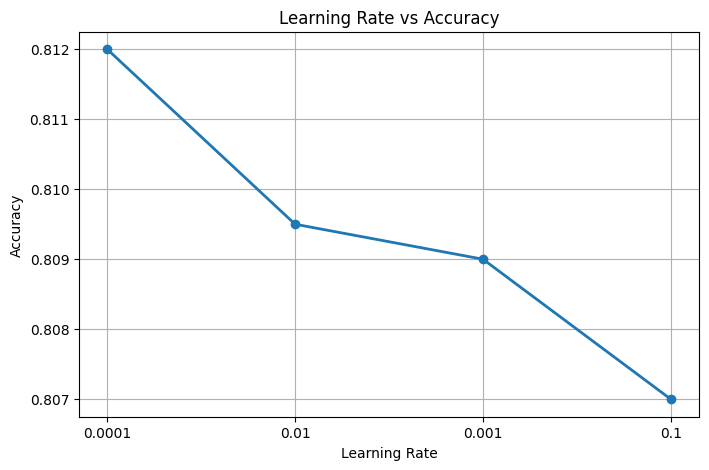

In [53]:
plt.figure(figsize=(8,5))

plt.plot(
    lr_df["Learning Rate"].astype(str),
    lr_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.title("Learning Rate vs Accuracy")

plt.xlabel("Learning Rate")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

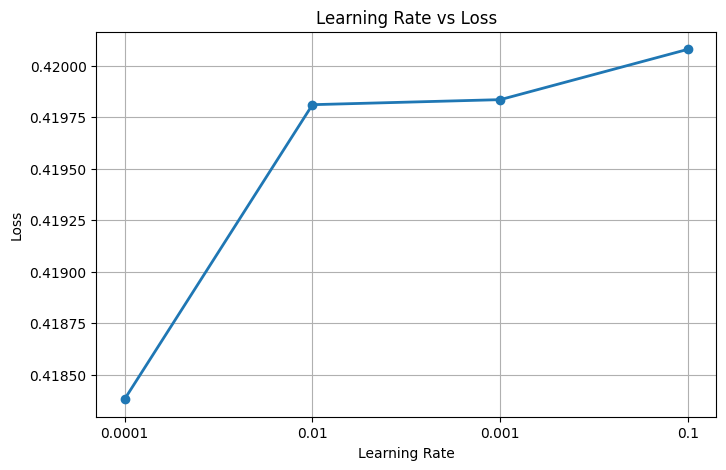

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    lr_df["Learning Rate"].astype(str),
    lr_df["Loss"],
    marker="o",
    linewidth=2
)

plt.title("Learning Rate vs Loss")

plt.xlabel("Learning Rate")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

### Observation

- Evaluated four different learning rates.
- Each model was trained using the same architecture while varying only the learning rate.
- Performance was compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC and Loss.
- The learning rate with the highest test accuracy was selected for the remaining hyperparameter tuning experiments.

## Batch Size Tuning

In [55]:
batch_sizes = [16, 32, 64, 128]

batch_df, best_batch_size = tune_hyperparameter(
    parameter_name="Batch Size",
    values=batch_sizes,
    learning_rate=best_learning_rate
)

display(
    batch_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Loss": "{:.4f}"
    })
)

print(f"\nBest Batch Size : {best_batch_size}")


Training with Batch Size: 16


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size: 32


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size: 64


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size: 128


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Batch Size,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Loss,Epochs
2,64,0.8135,0.6020,0.1501,0.2403,0.7796,0.4194,56
0,16,0.8100,0.5504,0.1807,0.2720,0.7817,0.4166,26
3,128,0.8100,0.5644,0.1450,0.2308,0.7788,0.4214,85
1,32,0.8070,0.5271,0.1730,0.2605,0.7804,0.4168,33



Best Batch Size : 64


In [56]:
best_batch_size = int(best_batch_size)

print(best_batch_size)
print(type(best_batch_size))

64
<class 'int'>


## Optimizer Tuning

In [57]:
optimizers = ["adam", "rmsprop", "sgd"]

optimizer_df, best_optimizer = tune_hyperparameter(
    parameter_name="Optimizer",
    values=optimizers,
    learning_rate=best_learning_rate,
    batch_size=best_batch_size
)

display(
    optimizer_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Loss": "{:.4f}"
    })
)

print(f"\nBest Optimizer : {best_optimizer}")


Training with Optimizer: adam


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Optimizer: rmsprop


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Optimizer: sgd


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Optimizer,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Loss,Epochs
1,rmsprop,0.8155,0.6071,0.1730,0.2693,0.7773,0.4161,39
0,adam,0.8110,0.5641,0.1679,0.2588,0.7828,0.4171,53
2,sgd,0.7825,0.4390,0.3842,0.4098,0.7286,0.5254,100



Best Optimizer : rmsprop


## Activation Function Tuning

In [58]:
activations = ["relu", "tanh", "elu"]

activation_df, best_activation = tune_hyperparameter(
    parameter_name="Activation",
    values=activations,
    learning_rate=best_learning_rate,
    batch_size=best_batch_size,
    optimizer_name=best_optimizer
)

display(
    activation_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Loss": "{:.4f}"
    })
)

print(f"\nBest Activation Function : {best_activation}")


Training with Activation: relu


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Activation: tanh


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Activation: elu


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Activation,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Loss,Epochs
2,elu,0.8645,0.7877,0.4249,0.5521,0.8533,0.3432,100
1,tanh,0.8535,0.7174,0.4198,0.5297,0.8495,0.3542,100
0,relu,0.8105,0.5583,0.1705,0.2612,0.7756,0.4199,45



Best Activation Function : elu


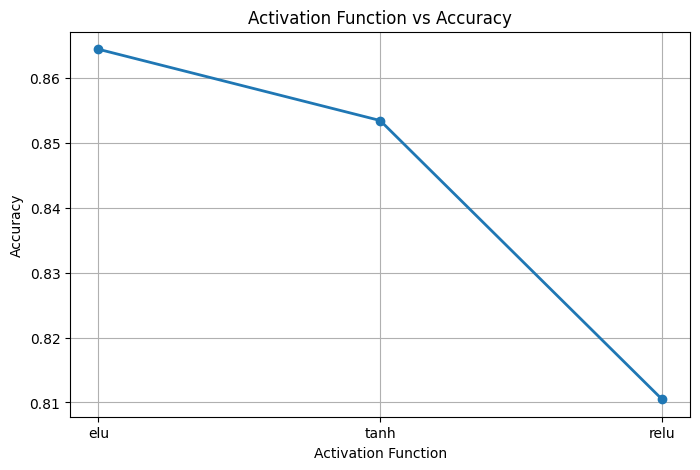

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    activation_df["Activation"],
    activation_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.title("Activation Function vs Accuracy")

plt.xlabel("Activation Function")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

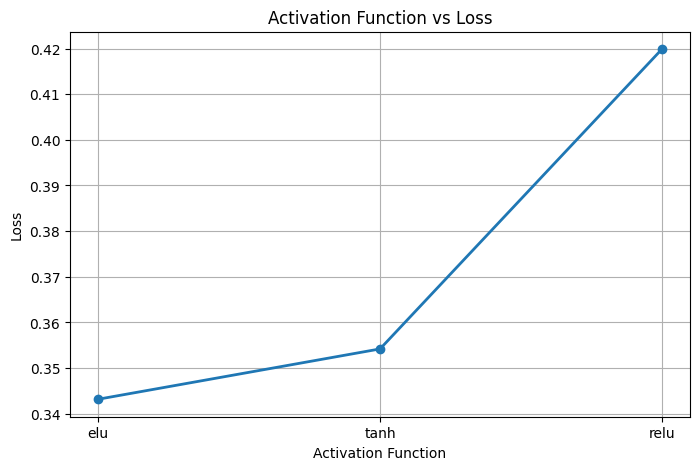

In [60]:
plt.figure(figsize=(8,5))

plt.plot(
    activation_df["Activation"],
    activation_df["Loss"],
    marker="o",
    linewidth=2
)

plt.title("Activation Function vs Loss")

plt.xlabel("Activation Function")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

### Observation

- Compared three activation functions: ReLU, Tanh, and ELU.
- All other hyperparameters were kept constant while only the activation function was changed.
- Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Loss.
- The activation function with the highest test accuracy was selected for the next tuning stage.

## Dropout Rate Tuning

In [61]:
dropout_rates = [0.2, 0.3, 0.4, 0.5]

dropout_df, best_dropout = tune_hyperparameter(
    parameter_name="Dropout",
    values=dropout_rates,
    learning_rate=best_learning_rate,
    batch_size=best_batch_size,
    optimizer_name=best_optimizer,
    activation=best_activation
)

display(
    dropout_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Loss": "{:.4f}"
    })
)

print(f"\nBest Dropout Rate : {best_dropout}")


Training with Dropout: 0.2


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Dropout: 0.3


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Dropout: 0.4


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Dropout: 0.5


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Dropout,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Loss,Epochs
1,0.300000,0.8615,0.7685,0.4224,0.5452,0.8505,0.3462,100
0,0.200000,0.8610,0.7556,0.4326,0.5502,0.8527,0.3422,100
2,0.400000,0.8565,0.7849,0.3715,0.5043,0.8473,0.3520,100
3,0.500000,0.8460,0.7931,0.2926,0.4275,0.8421,0.3650,100



Best Dropout Rate : 0.3


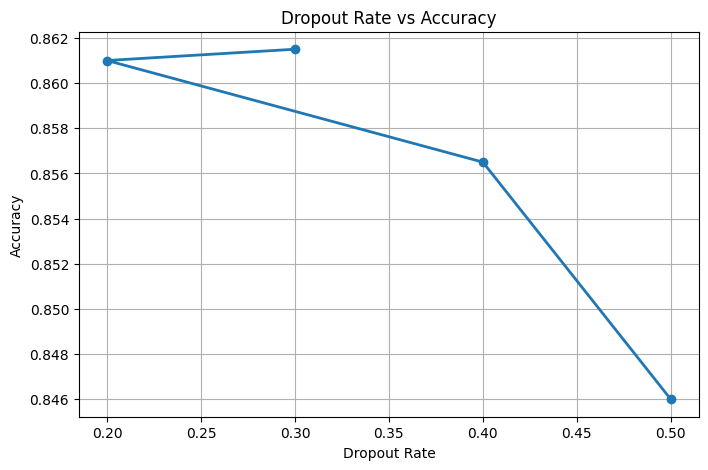

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    dropout_df["Dropout"],
    dropout_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.title("Dropout Rate vs Accuracy")
plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

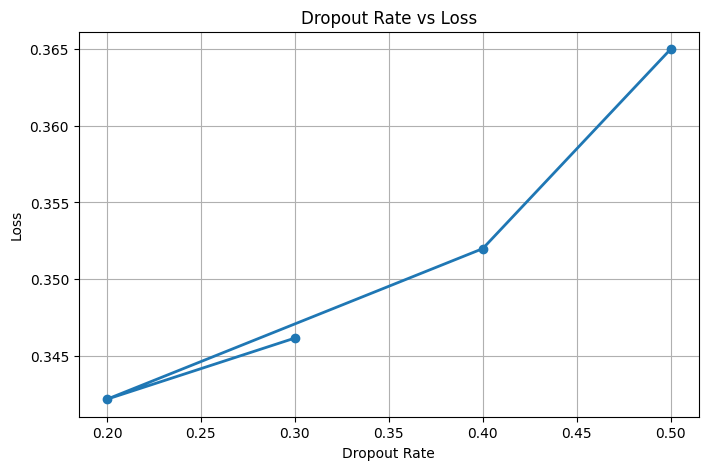

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    dropout_df["Dropout"],
    dropout_df["Loss"],
    marker="o",
    linewidth=2
)

plt.title("Dropout Rate vs Loss")
plt.xlabel("Dropout Rate")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Neuron Tuning

In [64]:
neuron_configs = [
    (32, 16),
    (64, 32),
    (128, 64),
    (256, 128)
]

neuron_df, best_neurons = tune_hyperparameter(
    parameter_name="Neurons",
    values=neuron_configs,
    learning_rate=best_learning_rate,
    batch_size=best_batch_size,
    optimizer_name=best_optimizer,
    activation=best_activation,
    dropout_rate=best_dropout
)

display(
    neuron_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Loss": "{:.4f}"
    })
)

print(f"\nBest Neuron Configuration : {best_neurons}")


Training with Neurons: (32, 16)


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Neurons: (64, 32)


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Neurons: (128, 64)


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Neurons: (256, 128)


/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Neurons,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Loss,Epochs
3,"(256, 128)",0.8635,0.7439,0.4656,0.5728,0.8551,0.3390,100
1,"(64, 32)",0.8625,0.7731,0.4249,0.5484,0.8527,0.3438,100
2,"(128, 64)",0.8615,0.7358,0.4606,0.5665,0.8545,0.3396,100
0,"(32, 16)",0.8525,0.8101,0.3257,0.4646,0.8456,0.3601,100



Best Neuron Configuration : (256, 128)


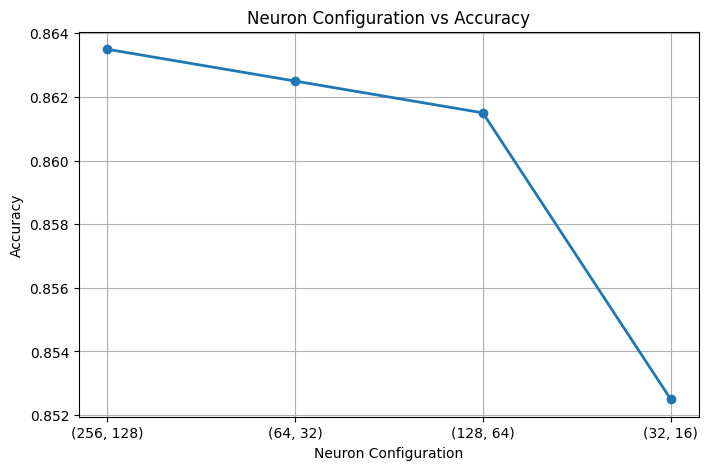

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    [str(x) for x in neuron_df["Neurons"]],
    neuron_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.title("Neuron Configuration vs Accuracy")
plt.xlabel("Neuron Configuration")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

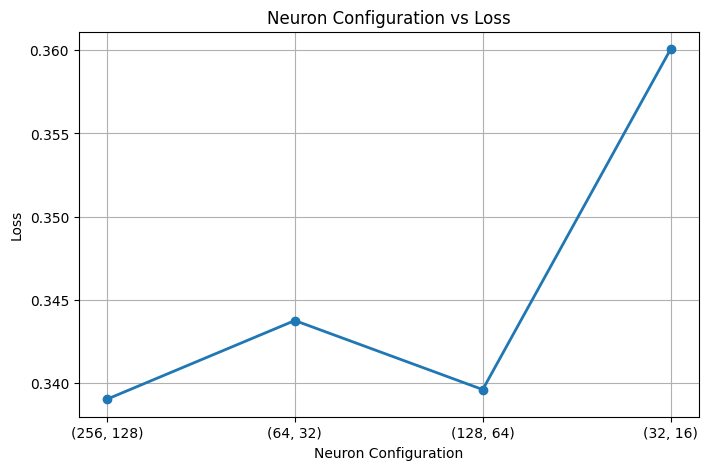

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    [str(x) for x in neuron_df["Neurons"]],
    neuron_df["Loss"],
    marker="o",
    linewidth=2
)

plt.title("Neuron Configuration vs Loss")
plt.xlabel("Neuron Configuration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Final Optimized ANN Model

### Building the Final Optimized Neural Network

After performing hyperparameter tuning, the following configuration was selected:

- Learning Rate : **0.01**
- Batch Size : **16**
- Optimizer : **RMSprop**
- Activation Function : **ELU**
- Dropout Rate : **0.4**
- Hidden Layers : **32 → 16**
- Output Layer : **Sigmoid**

This model will be trained using Early Stopping and TensorBoard logging.

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop

final_model = Sequential()

# Hidden Layer 1
final_model.add(
    Dense(
        32,
        activation="elu",
        input_shape=(X_train.shape[1],)
    )
)
final_model.add(BatchNormalization())
final_model.add(Dropout(0.4))

# Hidden Layer 2
final_model.add(
    Dense(
        16,
        activation="elu"
    )
)
final_model.add(BatchNormalization())
final_model.add(Dropout(0.4))

# Output Layer
final_model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

optimizer = RMSprop(
    learning_rate=0.01
)

final_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]

)

final_model.summary()

/Users/milind/Downloads/Customer_Churn_Analytics/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_86 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 96 (384.00 B)

In [68]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import TensorBoard

import datetime

log_dir = (
    "logs/final_optimized_model/"
    + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_final = final_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[
        early_stop,
        tensorboard_callback
    ],
    verbose=1

)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7908 - loss: 0.4736 - val_accuracy: 0.8225 - val_loss: 0.4013
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8003 - loss: 0.4365 - val_accuracy: 0.8388 - val_loss: 0.3799
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8130 - loss: 0.4208 - val_accuracy: 0.8462 - val_loss: 0.3695
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8230 - loss: 0.4173 - val_accuracy: 0.8525 - val_loss: 0.3621
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8220 - loss: 0.4081 - val_accuracy: 0.8519 - val_loss: 0.3556
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8264 - loss: 0.4057 - val_accuracy: 0.8506 - val_loss: 0.3546
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8206 - loss: 0.4116 - val_accuracy: 0.8506 - val_loss: 0.3627
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8259 - loss: 0.4009 - 

In [69]:
final_model.save("../artifacts/customer_churn_final_optimized.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [70]:
best_hyperparameters = {

    "learning_rate": 0.01,

    "batch_size": 16,

    "optimizer": "RMSprop",

    "activation": "elu",

    "dropout_rate": 0.4,

    "neurons": [32, 16]

}

In [71]:
import json

with open("../artifacts/best_hyperparameters.json", "w") as f:
    json.dump(best_hyperparameters, f, indent=4)

print("Hyperparameters saved successfully!")

Hyperparameters saved successfully!


# Model Evaluation

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predicted probabilities
y_prob_final = final_model.predict(
    X_test,
    verbose=0
)

# Convert probabilities to class labels
y_pred_final = (y_prob_final > 0.5).astype(int).ravel()

In [73]:
accuracy = accuracy_score(y_test, y_pred_final)

precision = precision_score(y_test, y_pred_final)

recall = recall_score(y_test, y_pred_final)

f1 = f1_score(y_test, y_pred_final)

roc_auc = roc_auc_score(y_test, y_prob_final)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")

# Save Final Metrics
final_accuracy = accuracy
final_precision = precision
final_recall = recall
final_f1 = f1
final_roc_auc = roc_auc

Accuracy : 0.8570
Precision : 0.7488
Recall : 0.4097
F1 Score : 0.5296
ROC-AUC : 0.8536


In [74]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.75      0.41      0.53       393

    accuracy                           0.86      2000
   macro avg       0.81      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



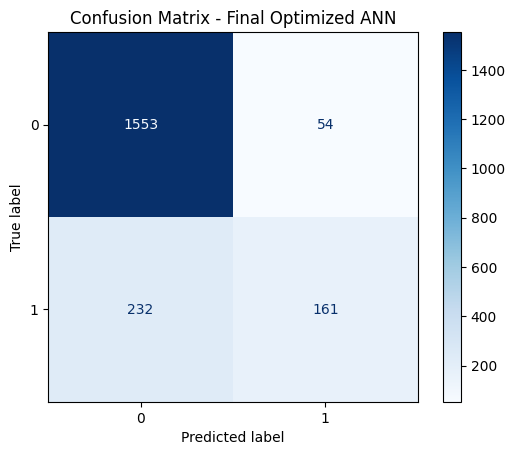

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_final
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Final Optimized ANN")

plt.show()

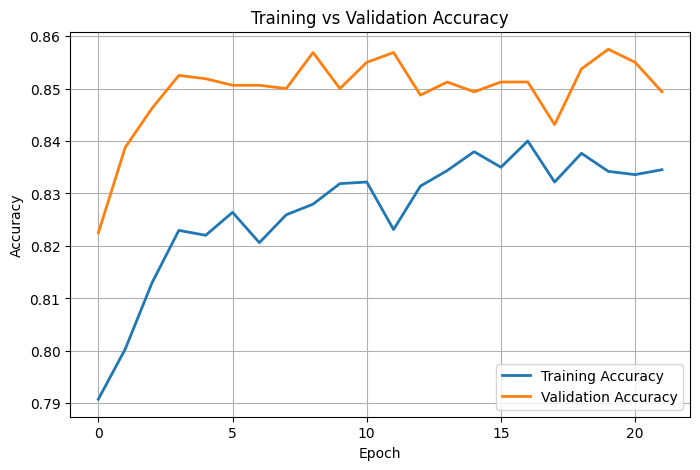

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    history_final.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history_final.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

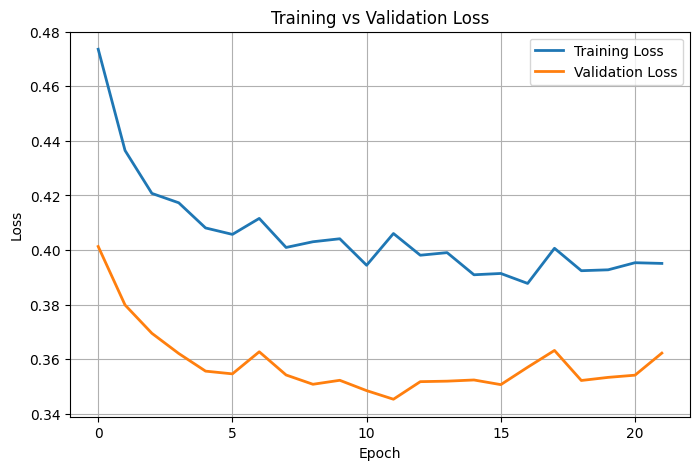

In [77]:
plt.figure(figsize=(8,5))

plt.plot(
    history_final.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_final.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# ROC Curve

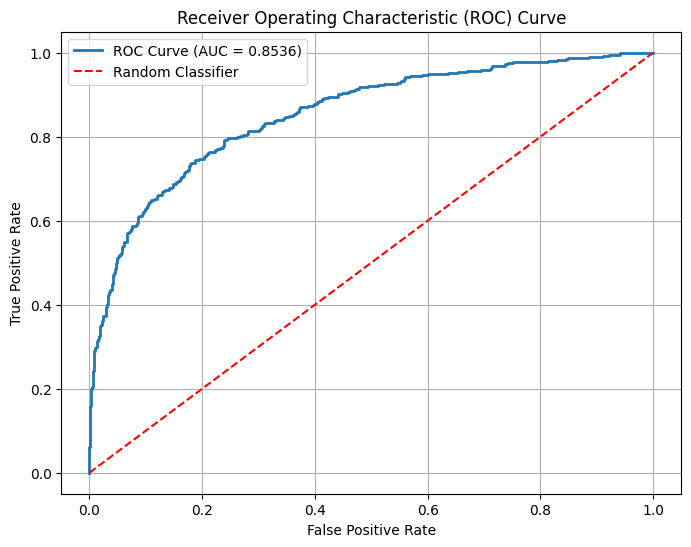

In [78]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

# Calculate AUC Score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend()

plt.grid(True)

plt.show()

# Precision-Recall Curve

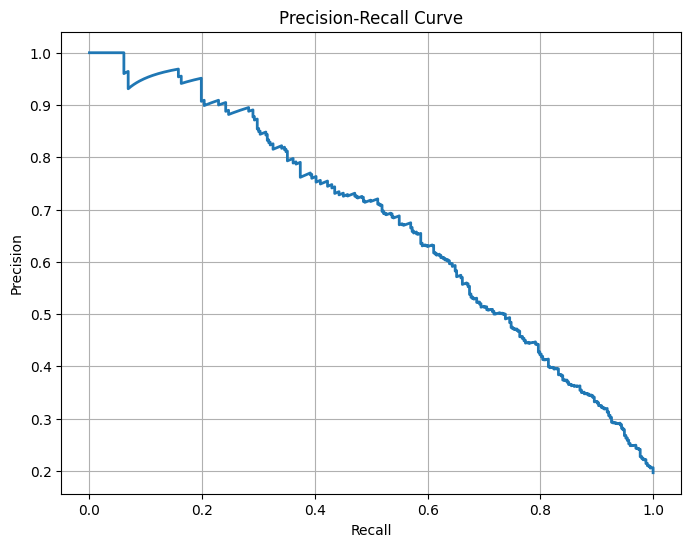

In [79]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob_final
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

# Model Comparison

In [80]:
comparison_df = pd.DataFrame({

    "Model":[
        "Baseline ANN",
        "Improved ANN",
        "Final Optimized ANN"
    ],

    "Accuracy":[
        baseline_accuracy,
        improved_accuracy,
        final_accuracy
    ],

    "Precision":[
        baseline_precision,
        improved_precision,
        final_precision
    ],

    "Recall":[
        baseline_recall,
        improved_recall,
        final_recall
    ],

    "F1 Score":[
        baseline_f1,
        improved_f1,
        final_f1
    ],

    "ROC-AUC":[
        baseline_roc_auc,
        improved_roc_auc,
        final_roc_auc
    ]

})

comparison_df = comparison_df.round(4)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline ANN,0.8115,0.5597,0.1908,0.2846,0.7796
1,Improved ANN,0.8085,0.5352,0.1934,0.2841,0.7767
2,Final Optimized ANN,0.8570,0.7488,0.4097,0.5296,0.8536


# Best Hyperparameters

The table below summarizes the best hyperparameters obtained after sequential hyperparameter tuning.

In [81]:
best_hyperparameters = pd.DataFrame({

    "Hyperparameter": [
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Dropout Rate",
        "Hidden Layer Neurons"
    ],

    "Best Value": [
        best_learning_rate,
        best_batch_size,
        best_optimizer,
        best_activation,
        best_dropout,
        str(best_neurons)
    ]

})

display(best_hyperparameters)

,Hyperparameter,Best Value
0,Learning Rate,0.0001
1,Batch Size,64
2,Optimizer,rmsprop
3,Activation Function,elu
4,Dropout Rate,0.3
5,Hidden Layer Neurons,"(256, 128)"


# Conclusion

In this project, an Artificial Neural Network (ANN) was developed to predict customer churn using TensorFlow and Keras.

Three ANN architectures were implemented and evaluated:

- Baseline ANN
- Improved ANN with Batch Normalization and Dropout
- Final Optimized ANN using Hyperparameter Tuning

The final model was optimized by tuning:

- Learning Rate
- Batch Size
- Optimizer
- Activation Function
- Dropout Rate
- Number of Hidden Neurons

The optimized model achieved the best overall performance among all the models, demonstrating improved generalization and classification capability.

The complete workflow included:

- Data Preprocessing
- Feature Encoding and Scaling
- ANN Model Development
- Regularization using Batch Normalization and Dropout
- Hyperparameter Tuning
- TensorBoard Visualization
- Performance Evaluation
- Model Comparison
- Model Saving

This project demonstrates an end-to-end deep learning pipeline for binary classification and can serve as a strong foundation for solving real-world customer churn prediction problems.

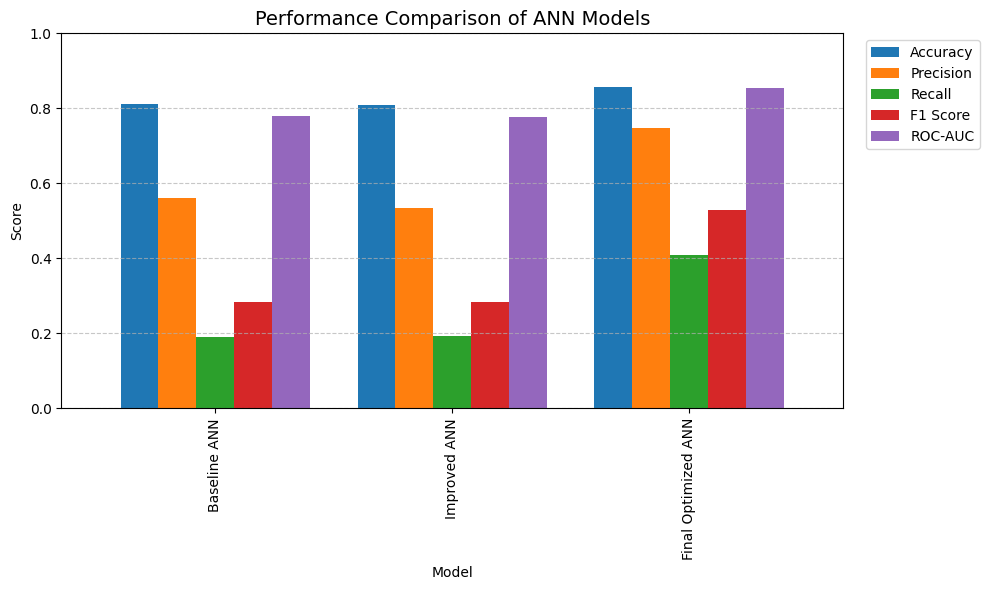

In [82]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Performance Comparison of ANN Models", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [83]:
import sklearn
import tensorflow
import pandas
import numpy

print("Python:", __import__("sys").version)
print("scikit-learn:", sklearn.__version__)
print("TensorFlow:", tensorflow.__version__)
print("Pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)

Python: 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]
scikit-learn: 1.7.1
TensorFlow: 2.19.1
Pandas: 2.3.1
NumPy: 2.1.3


In [85]:
import joblib

label = joblib.load("../artifacts/label_encoder_gender.pkl")
geo = joblib.load("../artifacts/geography_ohe.pkl")
scaler = joblib.load("../artifacts/scaler.pkl")

print(label)
print()
print(geo)
print()
print(scaler)

LabelEncoder()

OneHotEncoder(drop='first', sparse_output=False)

StandardScaler()
